# Heart Disease Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether a person has heart disease or not.

In [32]:
import pandas as pd
import numpy as np
HeartDiseaseData=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Classification Projects/Heart Disease/heart.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',HeartDiseaseData.shape)  
HeartDiseaseData.drop_duplicates(inplace=True)
print('Data After:deleting duplicate values',HeartDiseaseData.shape)
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None)  
HeartDiseaseData.head(10)

Data Before deleting duplicate values: (918, 12)
Data After:deleting duplicate values (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


### Target Variable:HeartDisease

## Exploratory Data Analysis

<Axes: xlabel='HeartDisease'>

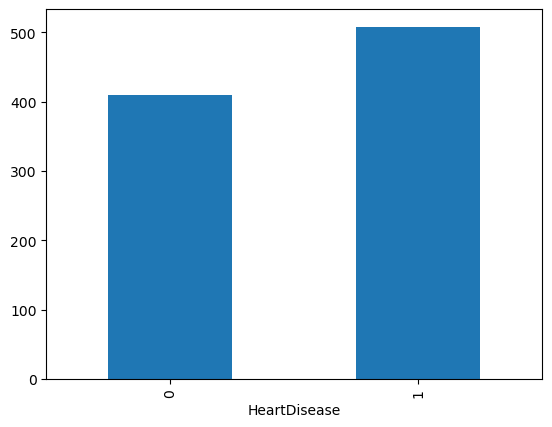

In [33]:
HeartDiseaseData.groupby('HeartDisease').size().plot(kind='bar')

In [34]:
HeartDiseaseData.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [35]:
HeartDiseaseData.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

### CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope', 'HeartDisease']
### ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']

In [36]:
HeartDiseaseData.shape

(918, 12)

In [37]:
HeartDiseaseData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [38]:
HeartDiseaseData.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Uni Variate Analysis by Bar Charts

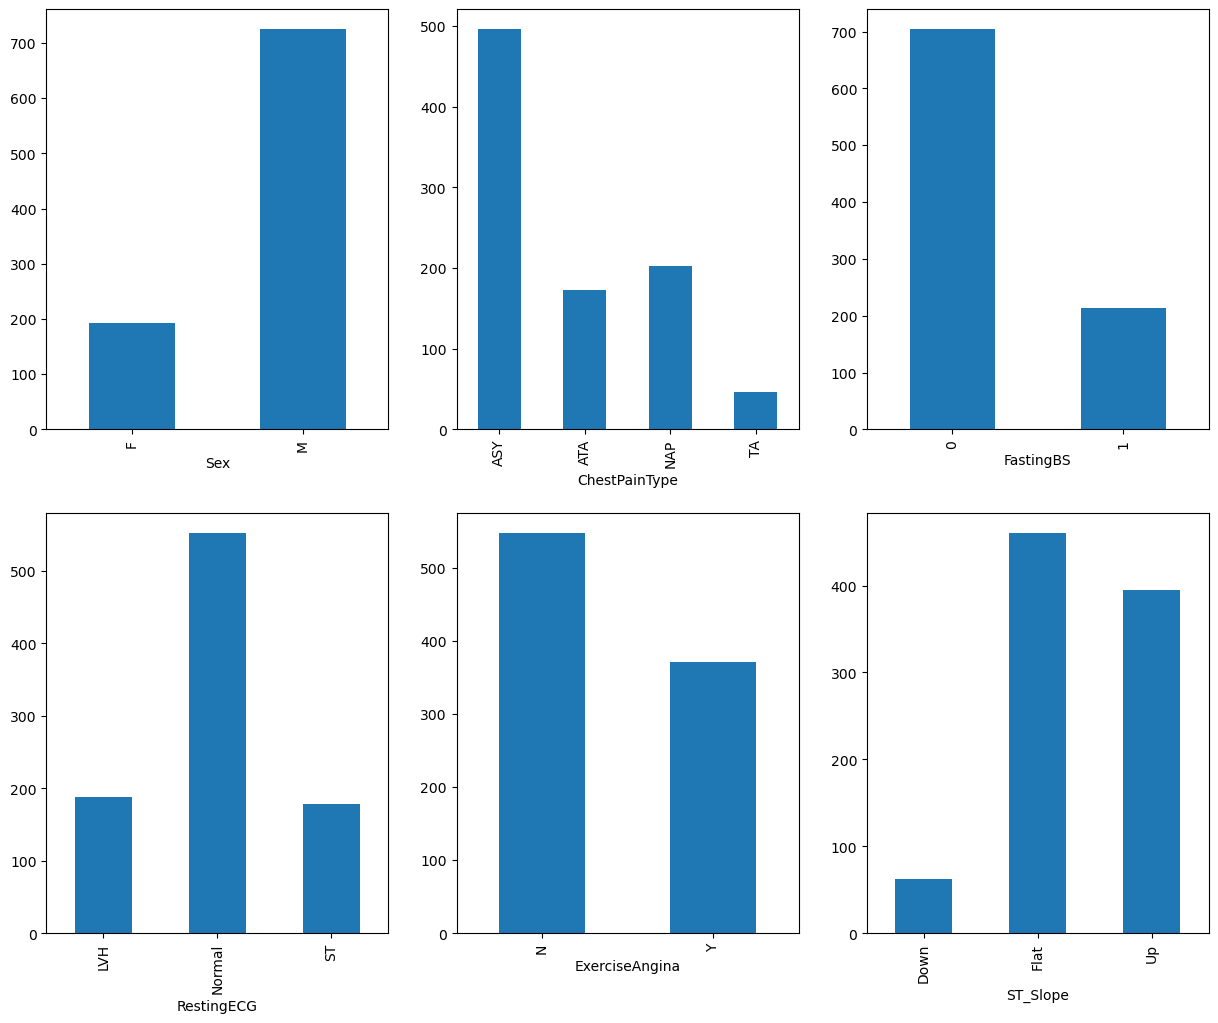

In [39]:
CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_columns in zip(CategoricalCols,range(len(CategoricalCols))):
    HeartDiseaseData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_columns])

### No need of imbalance treatment

## Uni Variate Analysis by Histogram

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'MaxHR'}>],
       [<Axes: title={'center': 'Oldpeak'}>, <Axes: >]], dtype=object)

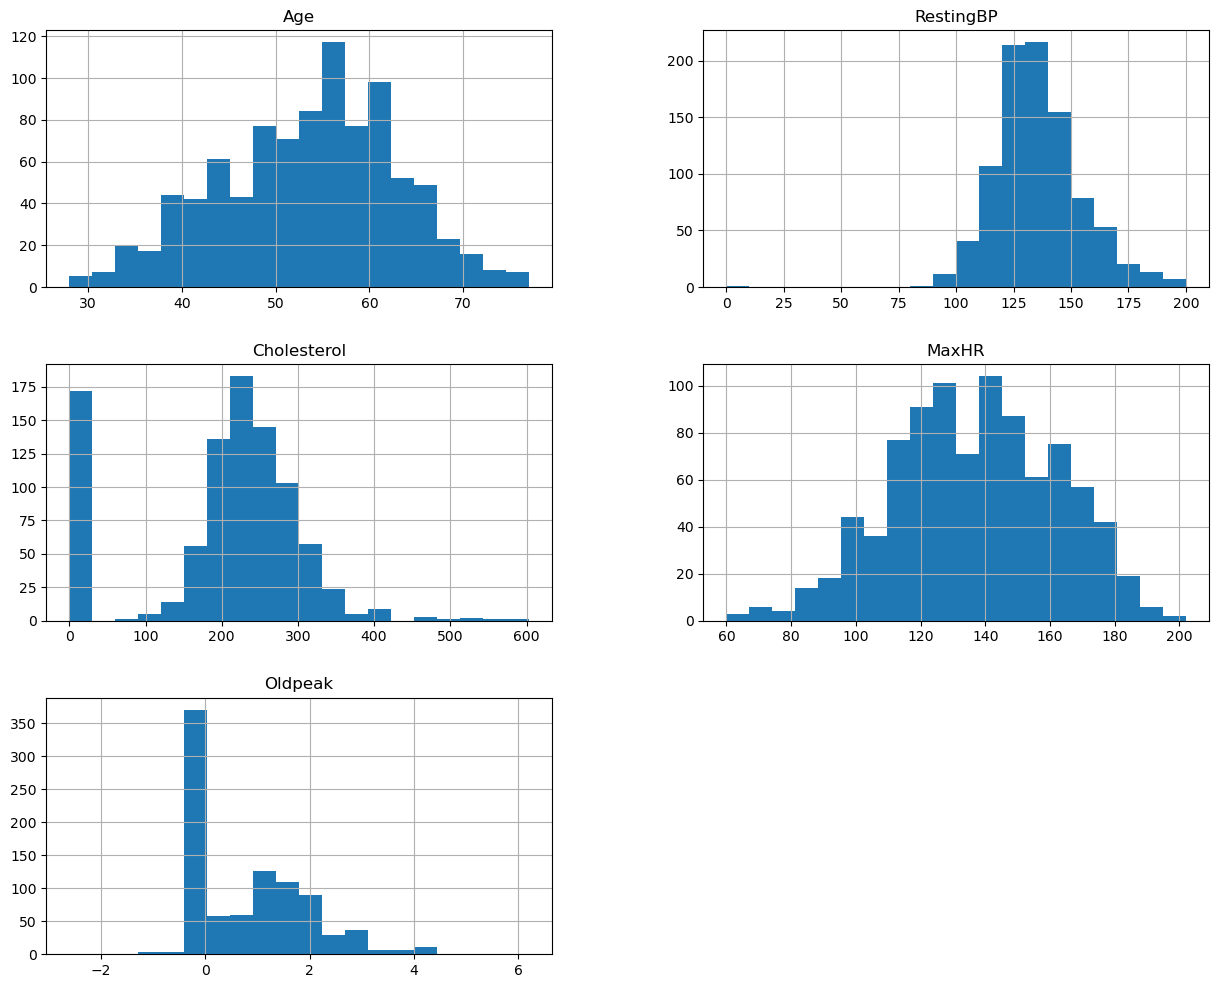

In [40]:
ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']
HeartDiseaseData[ContinousCols].hist(bins=20,figsize=(15,12))

## Outlier Treatment

In [41]:
HeartDiseaseData.loc[HeartDiseaseData['Cholesterol']>418,'Cholesterol']=417

<Axes: >

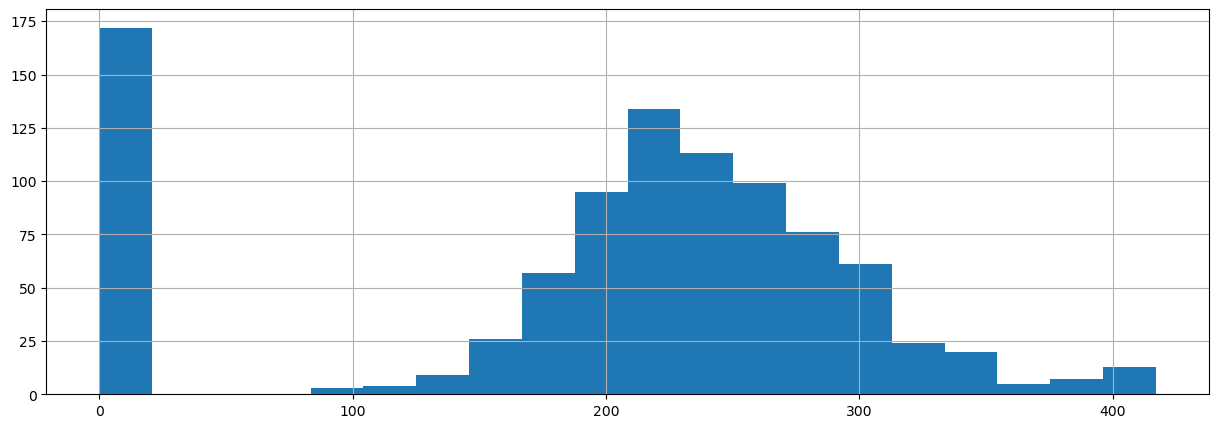

In [42]:
HeartDiseaseData['Cholesterol'].hist(bins=20,figsize=(15,5))


### No need of missing value treatment

In [43]:
HeartDiseaseData.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## Continous Vs Categorical Bivariate Analysis by Box Plots

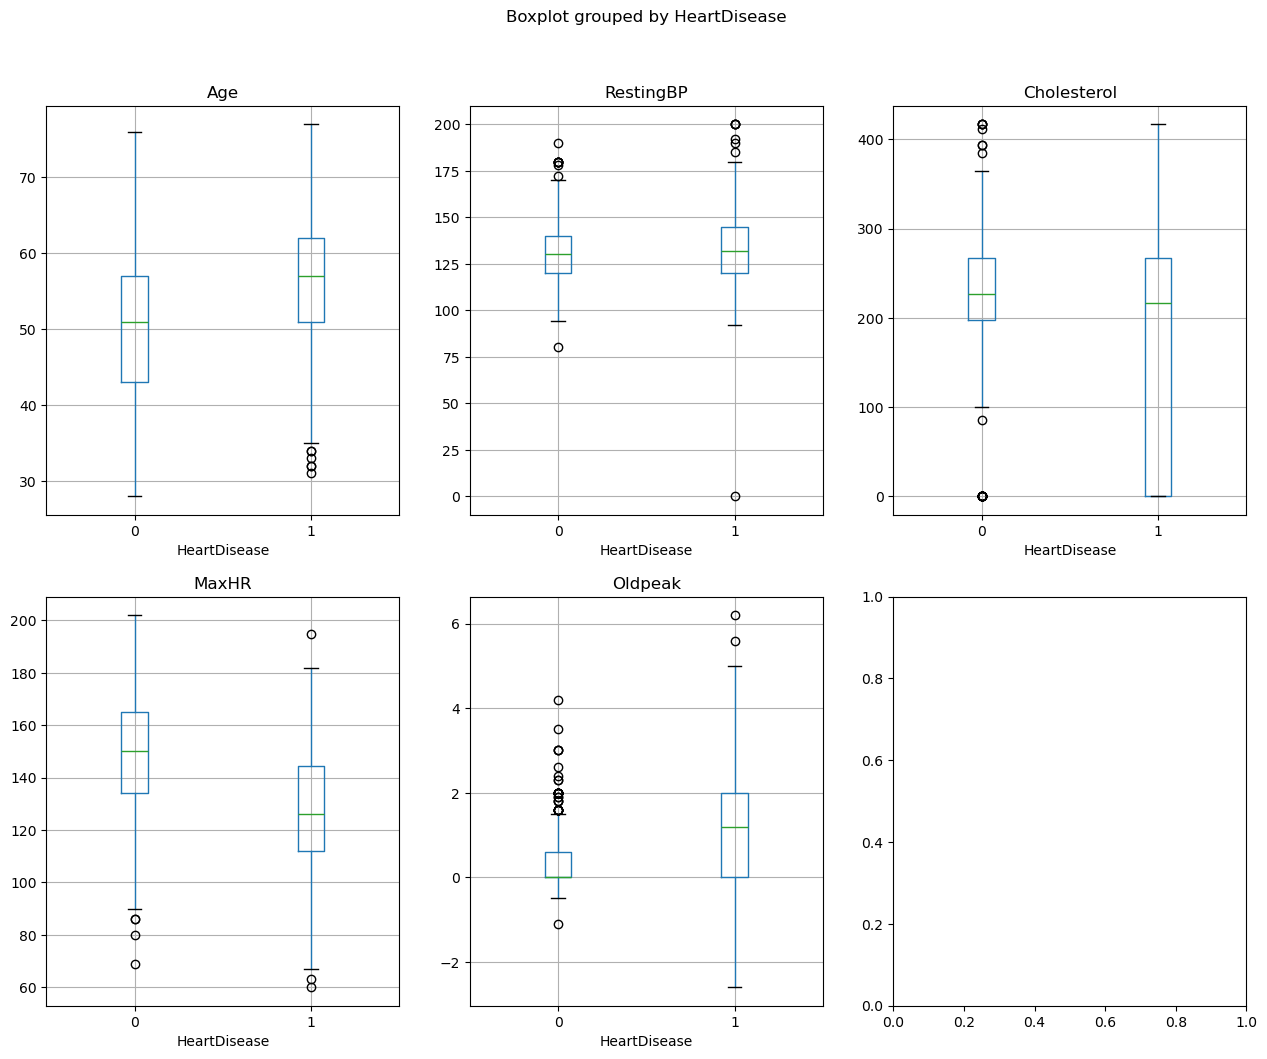

In [44]:
ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousCols,range(len(ContinousCols))):
    HeartDiseaseData.boxplot(column=cols,by='HeartDisease',vert=True,ax=subplots[no_of_cols])


## Statistical Feature Selection by Anova Function

In [45]:
ContinousCols=['Age','RestingBP', 'Cholesterol','MaxHR','Oldpeak']
SelectedPredictors=[]
from scipy.stats import f_oneway

for cols in ContinousCols:
    CategoricalGroupLists=HeartDiseaseData.groupby(cols)['HeartDisease'].apply(list)
    AnovaResults=f_oneway(*CategoricalGroupLists)
    if AnovaResults[1]<0.05:
        print(cols,' is corelated with HeartDisease and P values is:',AnovaResults[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not corelated with HeartDisease and P values is:',AnovaResults[1])
print(SelectedPredictors)
        
        

Age  is corelated with HeartDisease and P values is: 2.210523049940782e-09
RestingBP  is corelated with HeartDisease and P values is: 0.011298150619295956
Cholesterol  is corelated with HeartDisease and P values is: 1.275389750298296e-08
MaxHR  is corelated with HeartDisease and P values is: 8.761081954678646e-13
Oldpeak  is corelated with HeartDisease and P values is: 6.24095533400621e-29
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

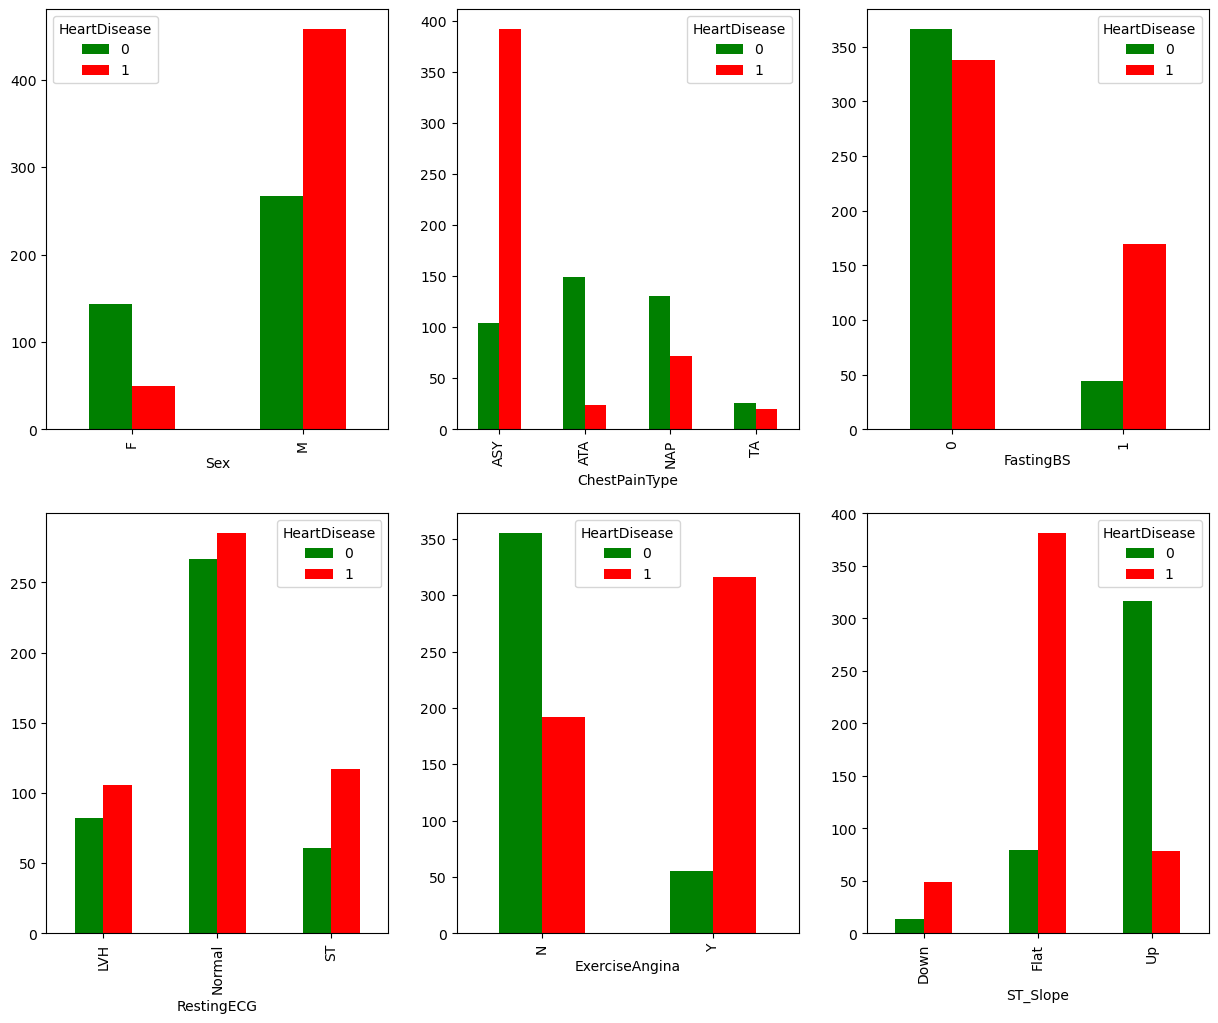

In [46]:
CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope']

import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    crosstabresults=pd.crosstab(columns=HeartDiseaseData['HeartDisease'],index=HeartDiseaseData[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols])


## Statistical Feature Selection by Chi2 Function

In [47]:
CategoricalCols=['Sex', 'ChestPainType','FastingBS', 'RestingECG','ExerciseAngina','ST_Slope']
SelectedPredictors=[]
from  scipy.stats  import chi2_contingency
for  cols in CategoricalCols:
    crosstabresults=pd.crosstab(columns=HeartDiseaseData['HeartDisease'],index=HeartDiseaseData[cols]) 
    chi2_results=chi2_contingency(crosstabresults) 
    if chi2_results[1]<0.05:
        print(cols,' is correlated with HeartDisease and p value is:',chi2_results[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not correlated with HeartDisease and p value is:',chi2_results[1])
SelectedPredictors

Sex  is correlated with HeartDisease and p value is: 4.597617450809164e-20
ChestPainType  is correlated with HeartDisease and p value is: 8.08372842808765e-58
FastingBS  is correlated with HeartDisease and p value is: 1.0573018731809955e-15
RestingECG  is correlated with HeartDisease and p value is: 0.0042292328167544925
ExerciseAngina  is correlated with HeartDisease and p value is: 2.907808387659878e-50
ST_Slope  is correlated with HeartDisease and p value is: 5.167637689470128e-78


['Sex',
 'ChestPainType',
 'FastingBS',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope']

## Selecting final predictors for Machine Learning

In [48]:
SelectedColumns=['Sex',
 'ChestPainType',
 'FastingBS',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

DataForMLHeartDiseaseData=HeartDiseaseData[SelectedColumns] 
DataForMLHeartDiseaseData.to_pickle('DataForMLHeartDiseaseData.pkl')
DataForMLHeartDiseaseData=pd.read_pickle('DataForMLHeartDiseaseData.pkl')

## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [49]:
DataForMLHeartDiseaseData_Numeric=pd.get_dummies(DataForMLHeartDiseaseData)
DataForMLHeartDiseaseData_Numeric.head()

,FastingBS,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0,40,140,289,172,0.0,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,0,49,160,180,156,1.0,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,0,37,130,283,98,0.0,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,0,48,138,214,108,1.5,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,0,54,150,195,122,0.0,False,True,False,False,True,False,False,True,False,True,False,False,False,True


## Converting the binary nominal variable to numeric using 1/0 mapping

In [50]:
DataForMLHeartDiseaseData_Numeric.replace({False:0,True:1},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_74180\34263691.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForMLHeartDiseaseData_Numeric.replace({False:0,True:1},inplace=True)


In [51]:
DataForMLHeartDiseaseData_Numeric.columns

Index(['FastingBS', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [52]:
DataForMLHeartDiseaseData_Numeric['HeartDisease']=HeartDiseaseData['HeartDisease']

## Splitting the data into Training and Testing sample

In [53]:
DataForMLHeartDiseaseData_Numeric.shape

(918, 21)

In [54]:
predictors=['FastingBS', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
#'Age','RestingBP','Oldpeak','Sex_M'
#predictors=[ 'Oldpeak',
 #   'ChestPainType_ASY', 'ST_Slope_Up'] 
targetVariable='HeartDisease'
X=DataForMLHeartDiseaseData_Numeric[predictors].values
y=DataForMLHeartDiseaseData_Numeric[targetVariable].values
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=5)

In [55]:
X_train[0:5]

array([[0.00e+00, 5.50e+01, 1.35e+02, 2.50e+02, 1.61e+02, 1.40e+00,
        1.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        1.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        1.00e+00, 0.00e+00],
       [0.00e+00, 6.30e+01, 1.32e+02, 0.00e+00, 1.30e+02, 1.00e-01,
        1.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 1.00e+00],
       [0.00e+00, 6.70e+01, 1.45e+02, 0.00e+00, 1.25e+02, 0.00e+00,
        0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 1.00e+00,
        1.00e+00, 0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00,
        1.00e+00, 0.00e+00],
       [1.00e+00, 5.70e+01, 1.30e+02, 3.11e+02, 1.48e+02, 2.00e+00,
        0.00e+00, 1.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
        0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 1.00e+00, 0.00e+00,
        1.00e+00, 0.00e+00],
       [0.00e+00, 4.60e+01, 1.40e+02, 3.11e+02, 1.20e+02, 1.80e+00,


In [56]:
y_train[0:5]

array([0, 0, 1, 1, 1])

## Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression
#'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=2,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction=LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuracy:',np.round((F1_Score),2)*100,'%')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

              precision    recall  f1-score   support

           0       0.89      0.92      0.91        73
           1       0.94      0.93      0.94       111

    accuracy                           0.92       184
   macro avg       0.92      0.92      0.92       184
weighted avg       0.92      0.92      0.92       184

[[ 67   6]
 [  8 103]]
Sample Data Accuracy: 92.0 %
[0.85358618 0.83736148 0.82391062 0.85698673 0.76021057]
Final Accuracy of the Model: 83.0 %


## Decision Tree

              precision    recall  f1-score   support

           0       0.76      0.93      0.84        73
           1       0.95      0.81      0.87       111

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184

[[68  5]
 [21 90]]
Sample Data Accuaracy: 86.0 %
[0.90189172 0.85911426 0.79787512 0.78874558 0.721714  ]
Final Accuracy of the Model: 81.0 %


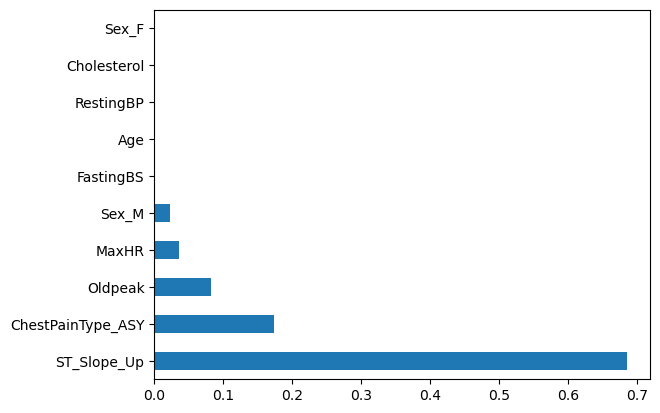

In [58]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=3,criterion='gini')
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuaracy:',np.round((F1_Score),2)*100,'%')
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DTree,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

## Random Forest Classifier

In [59]:
import matplotlib.pyplot as plt

RandomForestClassifier(oob_score=True)
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        73
           1       0.94      0.92      0.93       111

    accuracy                           0.92       184
   macro avg       0.91      0.92      0.92       184
weighted avg       0.92      0.92      0.92       184

[[ 67   6]
 [  9 102]]


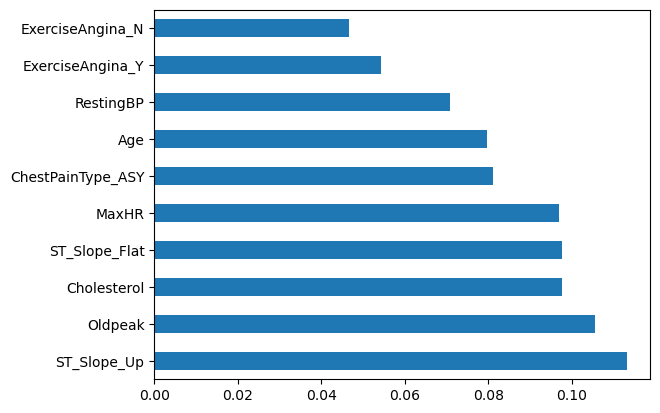

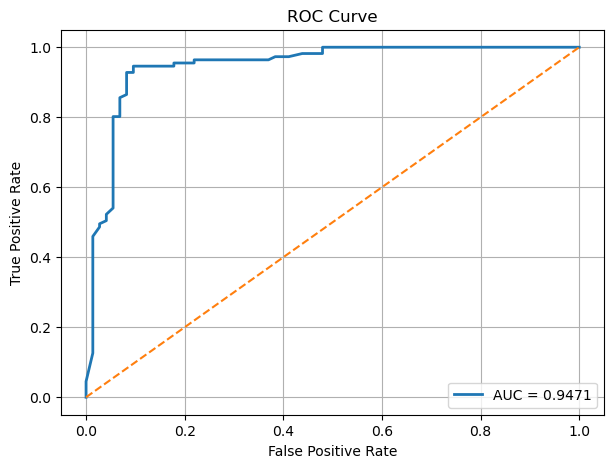

OOB Score: 86.0 %
OOB Error: 14.000000000000002 %
ROC-AUC Score: 0.9471


In [60]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,criterion='gini', oob_score=True)
print(clf)
 
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score

y_prob = RF.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


OOBScore = RF.oob_score_

print("OOB Score:", round(OOBScore,2)*100,'%')

OOBError = 1 - OOBScore

print("OOB Error:", round(OOBError,2)*100,'%')


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

In [61]:
#!pip install xgboost

In [62]:
#import sys
#!{sys.executable} -m pip install xgboost

In [63]:
#from xgboost import XGBClassifier

#print("XGBoost installed successfully!")

In [64]:
#import sys
#print(sys.executable) 

In [65]:
#import sys
#!{sys.executable} -m pip show xgboost

In [66]:
#import sys
#print(sys.executable)

#!{sys.executable} -m pip list

## XGBoost Classifier

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.92      0.93      0.93        73
           1       0.95      0.95      0.95       111

    accuracy                           0.94       184
   macro avg       0.94

,FastingBS,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,TargetColumn,Prediction
0,0.0,41.0,120.0,336.0,118.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1
1,0.0,48.0,100.0,159.0,100.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0
2,1.0,60.0,130.0,0.0,130.0,1.1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1,1
3,0.0,63.0,140.0,260.0,112.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,1
4,1.0,42.0,120.0,240.0,194.0,0.8,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0


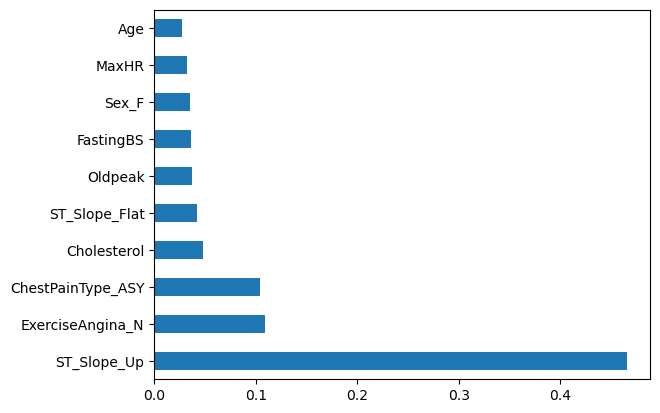

In [94]:
###### Xgboost Classification in Python #######
import pandas as pd 
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=2, learning_rate=0.1, n_estimators=50, objective='binary:logistic', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(clf)
 
#Creating the model on Training Data                                                                                                         

 

XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))

print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh') 
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction   
TestingDataResults.head()

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       0.88      0.93      0.91        73
           1       0.95      0.92      0.94       111

    accuracy                           0.92       184
   macro avg       0.92      0.93      0.92       184
weighted avg       0.93      0.92      0.92       184

[[ 68   5]
 [  9 102]]


,FastingBS,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,TargetColumn,Prediction
0,0.0,41.0,120.0,336.0,118.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1
1,0.0,48.0,100.0,159.0,100.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,0
2,1.0,60.0,130.0,0.0,130.0,1.1,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1,1
3,0.0,63.0,140.0,260.0,112.0,3.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,1
4,1.0,42.0,120.0,240.0,194.0,0.8,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0


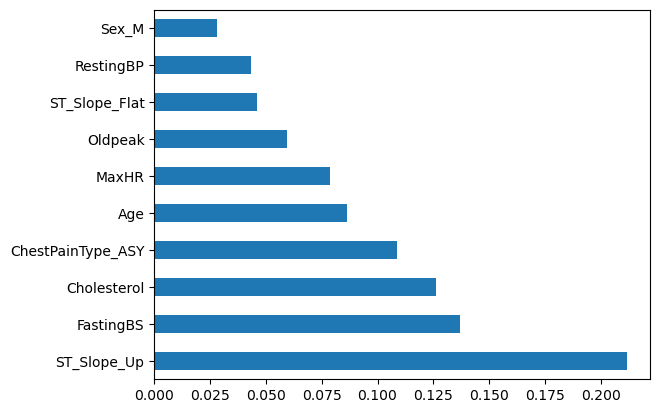

In [116]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=3)
clf = AdaBoostClassifier(n_estimators=100, estimator=DTC ,learning_rate=0.1)
 
#Printing all the parameters of Adaboost
print(clf)
 
#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()

In [ ]:
import sys
print(sys.executable)

In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [ ]:
import sys
print(sys.executable)
!where python
!pip show xgboost

# Selected XGBoost Classification Model for Deployment

## Deploying on Sample Production Data

In [117]:
NewData = pd.DataFrame(data=[
    [1.0, 59.0, 118.0, 28.0, 98.0, 0.6, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 67.0, 143.0, 277.0, 145.0, 0.4, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 64.0, 121.0, 14.0, 107.0, 1.5, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 60.0, 169.0, 359.0, 150.0, 0.5, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 63.0, 106.0, 0.0, 118.0, 1.5, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 67.0, 164.0, 424.0, 148.0, 0.5, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 68.0, 171.0, 357.0, 144.0, 0.4, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 79.0, 111.0, 129.0, 115.0, 3.6, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 66.0, 169.0, 367.0, 156.0, 0.8, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 77.0, 110.0, 69.0, 117.0, 3.3, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 45.0, 116.0, 171.0, 164.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 44.0, 103.0, 215.0, 162.0, 0.4, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 64.0, 155.0, 272.0, 142.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 59.0, 115.0, 4.0, 120.0, 1.1, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [1.0, 49.0, 98.0, 211.0, 151.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 64.0, 134.0, 293.0, 148.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 67.0, 167.0, 357.0, 148.0, 0.8, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 56.0, 96.0, 0.0, 106.0, 1.5, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [1.0, 44.0, 114.0, 186.0, 162.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 65.0, 136.0, 268.0, 159.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 67.0, 140.0, 235.0, 153.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 77.0, 104.0, 161.0, 118.0, 3.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 67.0, 160.0, 303.0, 155.0, 0.7, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 40.0, 95.0, 169.0, 153.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 65.0, 131.0, 248.0, 155.0, 0.4, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 56.0, 130.0, 209.0, 148.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 61.0, 156.0, 342.0, 150.0, 1.3, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 77.0, 102.0, 82.0, 107.0, 3.3, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 65.0, 128.0, 4.0, 122.0, 1.1, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 70.0, 94.0, 91.0, 137.0, 3.1, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 41.0, 110.0, 209.0, 155.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 62.0, 164.0, 346.0, 141.0, 0.2, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 72.0, 112.0, 0.0, 116.0, 2.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 66.0, 156.0, 393.0, 154.0, 1.6, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 70.0, 90.0, 163.0, 134.0, 3.4, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 74.0, 119.0, 80.0, 113.0, 3.8, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 76.0, 102.0, 123.0, 131.0, 3.5, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 68.0, 139.0, 359.0, 144.0, 0.2, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 44.0, 110.0, 157.0, 156.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 62.0, 120.0, 16.0, 125.0, 1.2, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 64.0, 162.0, 365.0, 142.0, 0.8, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 66.0, 185.0, 416.0, 144.0, 0.7, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 43.0, 104.0, 233.0, 150.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 35.0, 99.0, 165.0, 152.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 55.0, 95.0, 64.0, 104.0, 0.8, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 75.0, 175.0, 243.0, 149.0, 0.2, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 59.0, 108.0, 23.0, 117.0, 1.1, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 64.0, 146.0, 353.0, 149.0, 0.9, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 67.0, 170.0, 365.0, 154.0, 0.8, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 64.0, 103.0, 9.0, 113.0, 2.3, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 68.0, 138.0, 245.0, 162.0, 0.1, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 48.0, 84.0, 225.0, 160.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 77.0, 105.0, 104.0, 119.0, 3.4, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 66.0, 175.0, 283.0, 149.0, 0.9, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 74.0, 86.0, 123.0, 134.0, 2.7, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 80.0, 101.0, 111.0, 112.0, 3.3, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 69.0, 163.0, 313.0, 156.0, 0.9, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 67.0, 168.0, 351.0, 152.0, 0.5, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 58.0, 118.0, 0.0, 123.0, 1.7, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 75.0, 153.0, 231.0, 151.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 72.0, 116.0, 0.0, 106.0, 1.3, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 59.0, 153.0, 369.0, 160.0, 1.1, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 48.0, 102.0, 209.0, 169.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 43.0, 107.0, 150.0, 168.0, 0.2, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 63.0, 154.0, 310.0, 154.0, 0.1, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 47.0, 92.0, 193.0, 155.0, 0.2, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 59.0, 109.0, 44.0, 108.0, 0.9, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 66.0, 168.0, 360.0, 162.0, 1.2, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 68.0, 183.0, 354.0, 135.0, 1.6, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 63.0, 161.0, 399.0, 138.0, 0.2, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 61.0, 164.0, 376.0, 153.0, 0.1, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 34.0, 102.0, 183.0, 160.0, 0.4, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 63.0, 147.0, 301.0, 154.0, 0.3, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 61.0, 158.0, 366.0, 158.0, 0.6, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 75.0, 103.0, 138.0, 104.0, 2.9, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 59.0, 123.0, 258.0, 158.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 69.0, 123.0, 0.0, 125.0, 1.3, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 62.0, 140.0, 234.0, 145.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 73.0, 96.0, 12.0, 106.0, 1.5, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 65.0, 128.0, 306.0, 147.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 73.0, 108.0, 107.0, 123.0, 3.7, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 72.0, 157.0, 316.0, 160.0, 0.6, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 48.0, 100.0, 207.0, 172.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 65.0, 162.0, 392.0, 144.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [1.0, 48.0, 93.0, 149.0, 139.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 64.0, 143.0, 336.0, 161.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 74.0, 101.0, 119.0, 125.0, 3.3, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 51.0, 90.0, 197.0, 177.0, 0.1, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 65.0, 166.0, 358.0, 150.0, 0.4, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 68.0, 137.0, 298.0, 161.0, 0.2, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 66.0, 107.0, 28.0, 99.0, 1.1, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 66.0, 89.0, 154.0, 127.0, 3.1, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 51.0, 141.0, 351.0, 155.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [1.0, 66.0, 94.0, 0.0, 115.0, 1.3, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [0.0, 68.0, 153.0, 257.0, 159.0, 0.8, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0],
    [0.0, 71.0, 95.0, 153.0, 118.0, 4.2, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 72.0, 161.0, 368.0, 164.0, 0.6, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
    [0.0, 71.0, 100.0, 127.0, 107.0, 3.8, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0],
    [1.0, 70.0, 86.0, 0.0, 101.0, 0.9, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0],
    [1.0, 47.0, 99.0, 189.0, 155.0, 0.1, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0],
], columns=predictors)


In [119]:
newX=NewData.values

In [120]:
XGB.predict(newX)

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0])

In [121]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [122]:
GenerateSurvialPred(inpData=NewData)

,FastingBS,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Prediction
0,1.0,59.0,118.0,28.0,98.0,0.6,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1
1,0.0,67.0,143.0,277.0,145.0,0.4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,1.0,64.0,121.0,14.0,107.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1
3,0.0,60.0,169.0,359.0,150.0,0.5,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
4,1.0,63.0,106.0,0.0,118.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1
5,0.0,67.0,164.0,424.0,148.0,0.5,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
6,0.0,68.0,171.0,357.0,144.0,0.4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
7,0.0,79.0,111.0,129.0,115.0,3.6,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
8,0.0,66.0,169.0,367.0,156.0,0.8,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0
9,0.0,77.0,110.0,69.0,117.0,3.3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
